# HOT Station ALOHA -- Bottle Data -- Demo

Exploring the Hawaii Ocean Time-series (HOT) bottle data from CMAP to understand its structure, depth range, temporal coverage, and missingness before building any models.

CMAP Table: `tblHOT_Bottle_ALOHA`

## Import Packages

In [1]:
import pycmap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

import statsmodels.api as sm
import tensorflow as tf

# ── Helpers ──────────────────────────────────────────────────────────\
# compute R²
def r2_score(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res / ss_tot

def denorm(y_norm):
    return y_norm * y_std + y_mean

## CMAP Query

In [2]:
# api = pycmap.API(token='INSERT API KEY HERE') ### Edit API Key -- 

# table_name = 'tblHOT_Bottle_ALOHA'
# df = api.query(f"""
#     SELECT * FROM {table_name}
#     WHERE depth BETWEEN 0 AND 30
#     ORDER BY time
# """)

df = pd.read_csv('../hot_aloha_25m_full.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(17391, 68)
['time', 'lat', 'lon', 'depth', 'cruise_name', 'date_time', 'botid', 'press', 'theta', 'sigma', 'temp', 'csal', 'coxy', 'bsal', 'boxy', 'dic', 'ph', 'alk', 'phos', 'nit', 'sil', 'dop', 'don', 'doc', 'tdp', 'tdn', 'pc', 'pn', 'pp', 'lln', 'llp', 'chl', 'phaeo', 'chl3', 'chl12', 'chlplus', 'perid', 'but19', 'fuco', 'hex19', 'prasino', 'diadino', 'zeaxan', 'chlb', 'hplc', 'chlc4', 'acar', 'bcar', 'caroten', 'chlda', 'viol', 'lutein', 'mvchla', 'dvchla', 'hbact', 'pbact', 'sbact', 'ebact', 'atp', 'n2o', 'psi', 'pe4', 'pe5', 'pe10', 'p15n', 'l12', 'd12', 'no2']
                  time    lat  lon      depth cruise_name  date_time  \
0  1988-10-31T00:00:00  22.75 -158   4.670438      HOT001    15704.0   
1  1988-10-31T00:00:00  22.75 -158  10.632544      HOT001   150832.0   
2  1988-10-31T00:00:00  22.75 -158  25.338332      HOT001   150658.0   
3  1988-11-01T00:00:00  22.75 -158   4.074218      HOT001    63545.0   
4  1988-11-01T00:00:00  22.75 -158   7.651513      HOT001   21353

## Missing Data

Many variables in the HOT dataset are sparsely sampled.

We start with variables that are more consistently observed so that we have enough data to train on.

We then use these to estimate a more sparsely sampled variable, DIC.

Total measured variables: 60
Variables with >90% of rows missing: 52
Variables with <50% of rows missing: 5



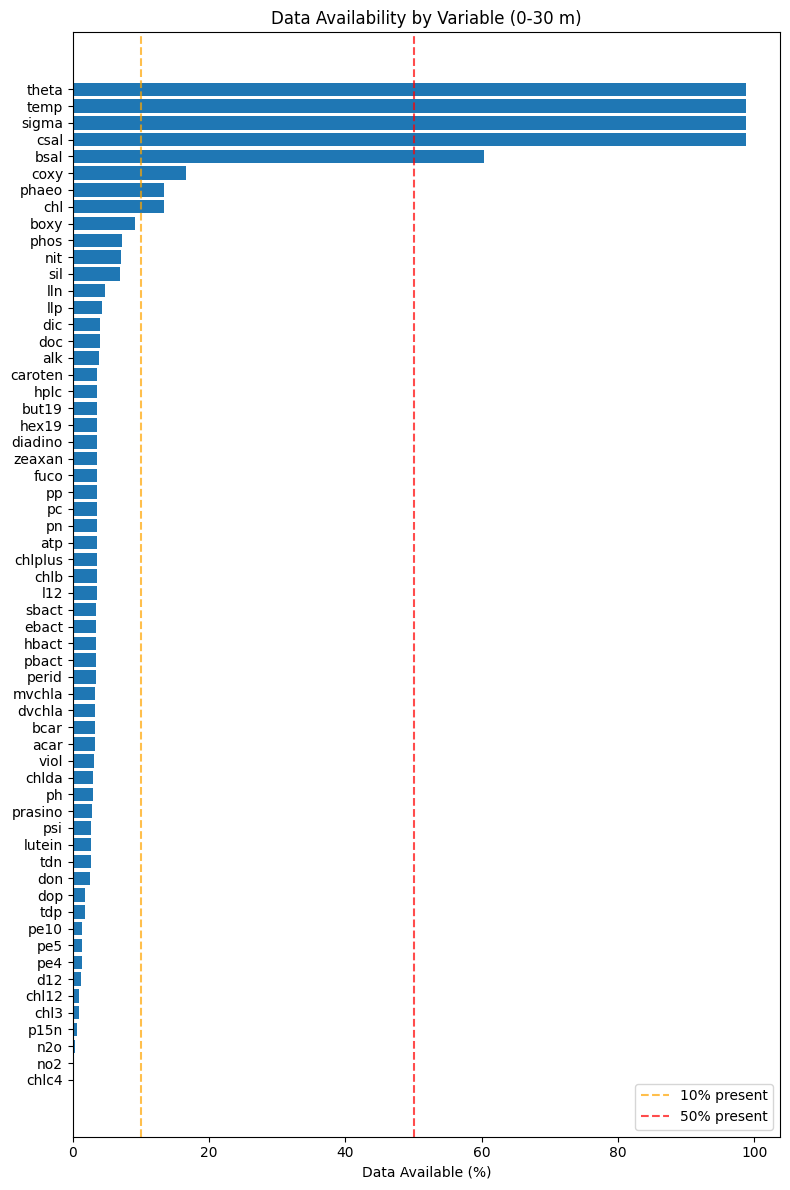

In [3]:
# ── Missingness by variable ──────────────────────────────────────────
meta_cols = ['time', 'lat', 'lon', 'depth', 'cruise_name', 'date_time', 'botid', 'press']
var_cols  = [c for c in df.columns if c not in meta_cols]

miss = df[var_cols].isna().mean().sort_values(ascending=False) * 100
print(f"Total measured variables: {len(var_cols)}")
print(f"Variables with >90% of rows missing: {(miss > 90).sum()}")
print(f"Variables with <50% of rows missing: {(miss < 50).sum()}\n")

# Data availability for each variable
avail_pct = (100 - miss).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 12))
ax.barh(avail_pct.index, avail_pct.values)
ax.axvline(10, color='orange', linestyle='--', alpha=0.7, label='10% present')
ax.axvline(50, color='red',    linestyle='--', alpha=0.7, label='50% present')
ax.set_xlabel('Data Available (%)')
ax.set_title('Data Availability by Variable (0-30 m)')
ax.legend()
plt.tight_layout()
plt.show()

Most variables are >90% missing at the row level.
What matters for us is which variables have enough data to work with and where the gaps are.

## Preparing Training Data

### Feature Engineering

Day-of-year is encoded cyclically as sin and cos so that the network understands that December and January are adjacent, not 365 days apart.

In [4]:
df['time'] = pd.to_datetime(df['time'])
df['doy_sin'] = np.sin(2 * np.pi * df['time'].dt.dayofyear / 365)
df['doy_cos'] = np.cos(2 * np.pi * df['time'].dt.dayofyear / 365)

# ── Prepare training data ────────────────────────────────────────────
predictors = ['temp', 'csal', 'doy_sin', 'doy_cos']
target = 'dic'

### Train/Test Split

We keep only rows where all selected variables are present, then randomly shuffle and split the data into training, validation, and test sets.

Because we are predicting from co-located measurements (not forecasting in time), random splitting is appropriate.

The model learns from the training set and is evaluated on held-out data it has never seen.

In [5]:
mask = df[predictors + [target]].notna().all(axis=1)
data = df.loc[mask, predictors + [target]].values.copy()
print(f"Complete rows: {len(data):,}")

# Shuffle data
rng = np.random.default_rng(42)
data = data[rng.permutation(len(data))]

# Define split sizes
n_total = len(data)
n_train = int(0.7 * n_total)
n_val   = int(0.15 * n_total)

# Split indices
train_data = data[:n_train]
val_data   = data[n_train:n_train + n_val]
test_data  = data[n_train + n_val:]

# Split into X and y
X_train = train_data[:, :len(predictors)]
y_train = train_data[:, len(predictors):]

X_val = val_data[:, :len(predictors)]
y_val = val_data[:, len(predictors):]

X_test = test_data[:, :len(predictors)]
y_test = test_data[:, len(predictors):]

print(f"Train: {X_train.shape[0]:,}")
print(f"Val:   {X_val.shape[0]:,}")
print(f"Test:  {X_test.shape[0]:,}")

Complete rows: 705
Train: 493
Val:   105
Test:  107


### Normalization

Neural networks train more effectively when inputs and targets have similar scales.

We subtract the mean and divide by the standard deviation, computed from the training set only.

Using training statistics for the test set avoids data leakage, where we would otherwise be using information about the distribution of the test set during training.

In [6]:
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
y_mean, y_std = y_train.mean(), y_train.std()

X_train_n = (X_train - X_mean) / X_std
X_val_n = (X_val - X_mean) / X_std
X_test_n  = (X_test  - X_mean) / X_std
y_train_n = (y_train - y_mean) / y_std
y_val_n = (y_val - y_mean) / y_std
y_test_n  = (y_test  - y_mean) / y_std

print(f"X_mean = {X_mean}")
print(f"X_std  = {X_std}")
print(f"y_mean = {y_mean:.2f}, y_std = {y_std:.2f}")


X_mean = [25.06597647 35.05808032 -0.03649197 -0.04954794]
X_std  = [1.24578088 0.21989257 0.70445722 0.7070738 ]
y_mean = 1982.97, y_std = 17.50


### Linear Regression Baseline

We first fit a simple linear model to establish a baseline.

If this performs well, a neural network may not be necessary.

In [7]:
### Linear Regression Baseline
model_lr = sm.OLS(y_train_n, sm.add_constant(X_train_n)).fit()

# Test set performance
# Predictions (normalized → original scale)
y_pred_lr_test = model_lr.predict(sm.add_constant(X_test_n))
y_pred_lr = y_pred_lr_test * y_std + y_mean

# Metrics (original scale)
lr_r2_test = r2_score(y_test, y_pred_lr)
lr_rmse_test = np.sqrt(np.mean((y_test.flatten() - y_pred_lr.flatten())**2))

print(f"\nTest R² (LR):  {lr_r2_test:.4f}")
print(f"Test RMSE (LR): {lr_rmse_test:.4f}")


Test R² (LR):  0.4913
Test RMSE (LR): 12.7593


The linear model explains about 49% of the variance in DIC.
This gives us a baseline to compare against.

## Why Neural Networks?

Linear regression captures linear relationships between variables, but many environmental processes are nonlinear and involve interactions between variables.

These nonlinearities can appear in the data in ways that linear models cannot capture, motivating the use of neural networks.

### Building and Compiling the Network

We define a simple feedforward network.

- Each layer applies a transformation to the inputs  
- Nonlinear activations allow the model to learn complex relationships  
- The final layer is linear since we are predicting a continuous value  

We compile the model with the Adam optimizer (with a specified learning rate) and mean squared error loss.

**Note:**  
Wider layers (more neurons) increase the model’s capacity to represent complex relationships.  
Deeper networks (more layers) can learn hierarchical patterns.  
Start simple and increase capacity only if the training loss suggests underfitting.  
If the gap between training and test loss grows, the model may be too complex for the available data.

In [52]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

# ── Build the network ────────────────────────────────────────────────
model = tf.keras.Sequential()
# ── Input layer ──────────────────────────────────────────────────────
model.add(tf.keras.layers.Input(shape=(len(predictors),)))
# ── Add hidden layers ────────────────────────────────────────────────
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))
# ── Output layer ─────────────────────────────────────────────────────
model.add(tf.keras.layers.Dense(1, activation='linear'))
# ── Compile: choose optimizer and loss function ──────────────────────
learning_rate = 1e-3       # Adam learning rate
nn_optimizer = tf.keras.optimizers.Adam(learning_rate)
nn_loss = 'mse'
model.compile(
    optimizer=nn_optimizer,
    loss=nn_loss
)

hidden_layers = [64, 64]
print(f"Architecture: {len(predictors)} -> {' -> '.join(str(h) for h in hidden_layers)} -> 1")

Architecture: 4 -> 64 -> 64 -> 1


#### Train and Evaluate

Use `model.fit()` to train the network.
Pass in the training data, validation data, and an `EarlyStopping` callback that monitors `val_loss`.

**Key training hyperparameters:**
- **Epochs**: number of training iterations  
- **Batch size**: number of samples used per update  
- **Early stopping**: stops training when validation loss no longer improves, helping prevent overfitting  

In [53]:
# ── Tensors ──────────────────────────────────────────────────────────
X_train_t = tf.constant(X_train_n, dtype=tf.float32)
X_val_t   = tf.constant(X_val_n,   dtype=tf.float32)
X_test_t  = tf.constant(X_test_n,  dtype=tf.float32)

y_train_t = tf.constant(y_train_n, dtype=tf.float32)
y_val_t   = tf.constant(y_val_n,   dtype=tf.float32)
y_test_t  = tf.constant(y_test_n,  dtype=tf.float32)

# ── Train ────────────────────────────────────────────────────────────
n_epochs      = 500        # maximum training epochs
patience      = 50         # stop if val_loss doesn't improve for this many epochs
batch_size    = 64         # number of samples per gradient update
hist = model.fit(
    X_train_t, y_train_t,
    validation_data=(X_val_t, y_val_t),
    epochs=n_epochs,
    batch_size=batch_size,
    verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        patience=patience,
        restore_best_weights=True,
        monitor='val_loss',
        mode='min'
    )]
)

# ── Predictions (original scale) ─────────────────────────────────────
pred_train = denorm(model.predict(X_train_t, verbose=0))
pred_val   = denorm(model.predict(X_val_t,   verbose=0))
pred_test  = denorm(model.predict(X_test_t,  verbose=0))

# ── Metrics ──────────────────────────────────────────────────────────
r2_train = r2_score(y_train, pred_train)
r2_val   = r2_score(y_val,   pred_val)
r2_test  = r2_score(y_test,  pred_test)

rmse_test = np.sqrt(np.mean((y_test - pred_test)**2))

# ── Report ───────────────────────────────────────────────────────────
print(f"Training epochs run: {len(hist.history['loss'])}")

print(f"Final train loss: {hist.history['loss'][-1]:.6f}")
print(f"Final val loss:   {hist.history['val_loss'][-1]:.6f}")

print(f"Best val loss: {min(hist.history['val_loss']):.6f}\n")

print(f"Train R²: {r2_train:.4f}")
print(f"Val   R²: {r2_val:.4f}")
print(f"Test  R²: {r2_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")

Training epochs run: 186
Final train loss: 0.175861
Final val loss:   0.291355
Best val loss: 0.285703

Train R²: 0.7935
Val   R²: 0.7359
Test  R²: 0.6471
Test RMSE: 10.6279


#### Training Curve

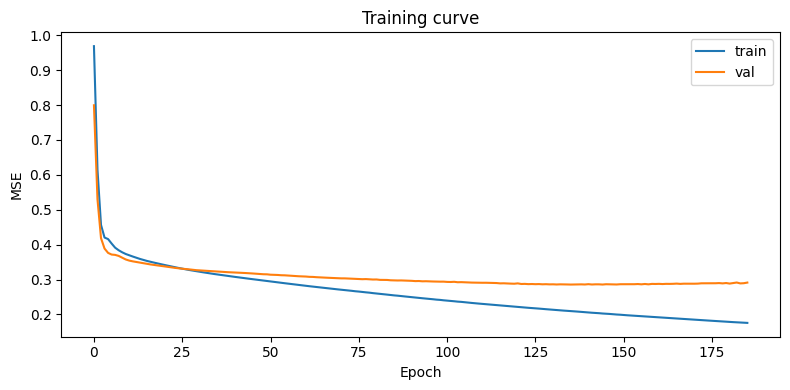

In [54]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist.history['loss'], label='train')
ax.plot(hist.history['val_loss'], label='val')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('Training curve')
ax.legend()
plt.tight_layout()
plt.show()

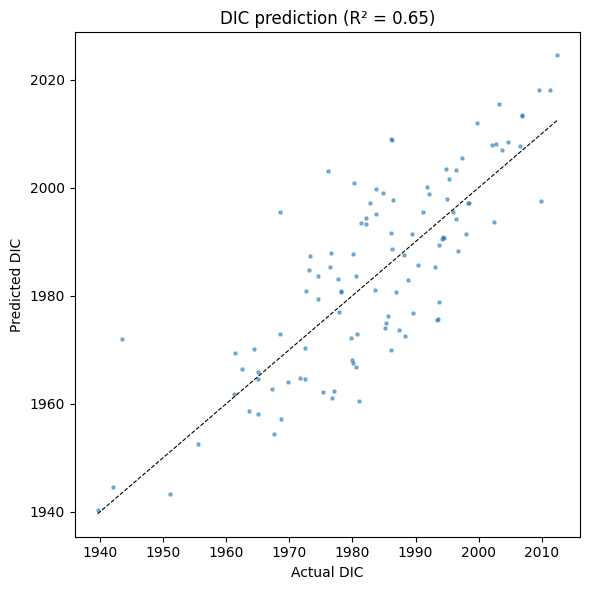

In [55]:
# ── Predicted vs actual ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pred_test, y_test, s=5, alpha=0.5)
lo, hi = pred_test.min(), pred_test.max()
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
ax.set_xlabel('Actual DIC')
ax.set_ylabel('Predicted DIC')
ax.set_title(f'DIC prediction (R² = {r2_test:.2f})')
plt.tight_layout()
plt.show()


In [56]:
display(Markdown(
    f"$R^2 = {r2_test:.2f}$ means the network captures about "
    f"{r2_test*100:.0f}% of the DIC variability from physical measurements alone.\n\n"
    "The predicted vs. observed plot follows the general trend across the full range of observed DIC values, but with considerable scatter. "
    "The remaining variance reflects processes that temperature and salinity alone cannot capture."
))

$R^2 = 0.65$ means the network captures about 65% of the DIC variability from physical measurements alone.

The predicted vs. observed plot follows the general trend across the full range of observed DIC values, but with considerable scatter. The remaining variance reflects processes that temperature and salinity alone cannot capture.

### Gap-filling
With the trained network, we can estimate DIC for every row where temperature and salinity exist but DIC was not measured.

In [57]:
# ── Fill missing DIC ─────────────────────────────────────────────────
has_predictors = df[predictors].notna().all(axis=1)
missing_dic = df['dic'].isna()
to_fill = has_predictors & missing_dic

X_fill = df.loc[to_fill, predictors].values
X_fill_n = (X_fill - X_mean) / X_std
pred_fill_n = model.predict(tf.constant(X_fill_n, dtype=tf.float32), verbose=0)
pred_fill = pred_fill_n * y_std + y_mean

print(f"Rows with predictors but missing DIC: {to_fill.sum():,}")
print(f"Predicted DIC range: {pred_fill.min():.1f} to {pred_fill.max():.1f}")
print(f"Training DIC range:  {y_train.min():.1f} to {y_train.max():.1f}")

Rows with predictors but missing DIC: 16,471
Predicted DIC range: 1935.5 to 2021.6
Training DIC range:  1937.7 to 2027.6


In [58]:
display(Markdown(
    f"""
The trained network can now estimate DIC for every row where temperature and salinity exist, 
filling in **{to_fill.sum():,}** observations that lack direct DIC measurements.

The predicted range ({pred_fill.min():.0f}–{pred_fill.max():.0f}) does not fully reach the highest 
observed training values ({y_train.max():.0f}), suggesting the network may underrepresent extreme values.
"""
))


The trained network can now estimate DIC for every row where temperature and salinity exist, 
filling in **16,471** observations that lack direct DIC measurements.

The predicted range (1936–2022) does not fully reach the highest 
observed training values (2028), suggesting the network may underrepresent extreme values.


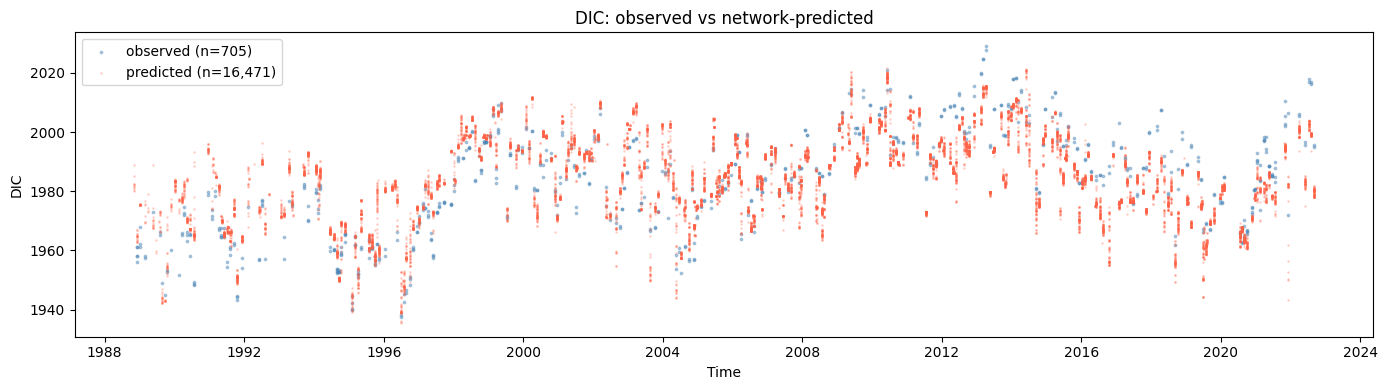

In [59]:
# ── Plot observed vs filled DIC ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

# Observed
obs_mask = df['dic'].notna()
ax.scatter(df.loc[obs_mask, 'time'], df.loc[obs_mask, 'dic'], s=3, alpha=0.4,
           color='steelblue', label=f'observed (n={obs_mask.sum():,})')

# Filled
ax.scatter(df.loc[to_fill, 'time'], pred_fill, s=1, alpha=0.2,
           color='tomato', label=f'predicted (n={to_fill.sum():,})')

ax.set_xlabel('Time')
ax.set_ylabel('DIC')
ax.set_title('DIC: observed vs network-predicted')
ax.legend()
plt.tight_layout()
plt.show()


The network fills 16,471 missing DIC values using the nearly complete temperature and salinity record.

### Explore Other Combinations

The same approach can be applied to other target variables.
Use the helper below to check how much training data is available for different predictor/target combinations before rebuilding the model above.

In [60]:
# How much training data would you have for different predictor/target combinations?
def check_overlap(df, predictors, target):
    cols = predictors + [target]
    n = df[cols].notna().all(axis=1).sum()
    print(f"Predictors: {predictors}")
    print(f"Target:     {target}")
    print(f"Complete rows: {n:,}\n")

check_overlap(df, ['temp', 'csal'], 'dic')
check_overlap(df, ['temp', 'csal'], 'coxy')
check_overlap(df, ['temp', 'csal'], 'phos')
check_overlap(df, ['temp', 'csal', 'phaeo'], 'dic')

Predictors: ['temp', 'csal']
Target:     dic
Complete rows: 705

Predictors: ['temp', 'csal']
Target:     coxy
Complete rows: 2,880

Predictors: ['temp', 'csal']
Target:     phos
Complete rows: 1,246

Predictors: ['temp', 'csal', 'phaeo']
Target:     dic
Complete rows: 171

